# Multi-Trajectory Parameter Estimation for Vehicle Model

This notebook performs global parameter estimation using all available real-world trajectory data.

## Approach:
1. Load all CSV files from `../data/measurements/`
2. Extract trajectories and controls from each file
3. Set up optimization problem to find best parameters (μ, C_d, m)
4. Use global optimization to minimize difference between simulated and real trajectories
5. Evaluate fit quality across all trajectories

## Parameters to Estimate:
- **μ (mu)**: Friction coefficient [0.5 - 1.5]
- **C_d (cd)**: Air resistance coefficient [0.05 - 0.60]
- **m (mass)**: Vehicle mass [1700 - 2200] kg

In [1]:
import sys
import os
from pathlib import Path

# Add parent directory to path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import jax
import jax.numpy as jnp
from scipy.optimize import differential_evolution, minimize
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import glob

# Import project modules
from simulation.simulation import rollout_with_states
from simulation.VehicleModel import default_params
from utils.real_data import (
    prep_x_obs_from_df,
    make_controls_from_df,
    initial_state_from_obs,
)

print("✓ Imports successful")
print(f"JAX devices: {jax.devices()}")

c:\Users\aritr\anaconda3\envs\sbi_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Imports successful
JAX devices: [CpuDevice(id=0)]


## 1. Load All Real Trajectory Data

In [2]:
# Path to measurements directory
data_dir = Path("../../data/measurements")

# Find all CSV files
csv_files = sorted(glob.glob(str(data_dir / "*.csv")))

print(f"Found {len(csv_files)} CSV files:")
for i, f in enumerate(csv_files, 1):
    fname = Path(f).name
    print(f"  {i}. {fname}")

Found 7 CSV files:
  1. Jeversen_2021_12_15_112145_Asphalt-Vollbremsung.csv
  2. Jeversen_2021_12_15_112328_Asphalt-Vollbremsung.csv
  3. Jeversen_2021_12_15_125650_Beton-Vollbremsung.csv
  4. Jeversen_2021_12_15_125936_Beton-Vollbremsung.csv
  5. Jeversen_2021_12_15_134709_Basalt-Vollbremsung.csv
  6. Jeversen_2021_12_15_134858_Basalt-Vollbremsung.csv
  7. Jeversen_2022_10_12_110132.csv


In [3]:
# Load all CSV files and inspect their lengths
dataframes = {}

for csv_path in csv_files:
    fname = Path(csv_path).stem
    df = pd.read_csv(csv_path)
    dataframes[fname] = df
    print(f"{fname}: {len(df)} rows")

print(f"\nTotal trajectories loaded: {len(dataframes)}")

Jeversen_2021_12_15_112145_Asphalt-Vollbremsung: 1070 rows
Jeversen_2021_12_15_112328_Asphalt-Vollbremsung: 1436 rows
Jeversen_2021_12_15_125650_Beton-Vollbremsung: 1189 rows
Jeversen_2021_12_15_125936_Beton-Vollbremsung: 1263 rows
Jeversen_2021_12_15_134709_Basalt-Vollbremsung: 1377 rows
Jeversen_2021_12_15_134858_Basalt-Vollbremsung: 1356 rows
Jeversen_2022_10_12_110132: 3165 rows

Total trajectories loaded: 7


## 2. Extract Trajectories and Controls

We'll extract consistent-length segments from each CSV file.

In [4]:
# Configuration
T_SEG = 1000  # Use 1000 timesteps (10 seconds at 0.01s dt)
START_OFFSET = 100  # Skip first 100 timesteps to avoid initialization issues

# Storage for extracted data
trajectories = []

for fname, df in dataframes.items():
    n_rows = len(df)
    
    # Check if we have enough data
    if n_rows < START_OFFSET + T_SEG:
        print(f"⚠ Skipping {fname}: only {n_rows} rows (need {START_OFFSET + T_SEG})")
        continue
    
    # Extract observations and controls
    try:
        x_obs = prep_x_obs_from_df(
            df,
            start_idx=START_OFFSET,
            T=T_SEG,
            rate_body_z_in_deg_s=True,
            tire_rates_in_rpm=True,
            vel_body_in_kmh=True,
        )
        
        controls = make_controls_from_df(
            df,
            start_idx=START_OFFSET,
            T=T_SEG,
            steer_in_deg=True,
        )
        
        # Get initial state
        y0 = x_obs[0].numpy()
        state0 = initial_state_from_obs(y0)
        
        trajectories.append({
            'name': fname,
            'x_obs': x_obs.numpy(),  # (T, 9)
            'controls': controls,     # dict of jnp arrays
            'state0': state0,         # (10,)
        })
        
        print(f"✓ {fname}: extracted {T_SEG} timesteps")
        
    except Exception as e:
        print(f"✗ Error processing {fname}: {e}")

print(f"\n✓ Successfully extracted {len(trajectories)} trajectories")

⚠ Skipping Jeversen_2021_12_15_112145_Asphalt-Vollbremsung: only 1070 rows (need 1100)
✓ Jeversen_2021_12_15_112328_Asphalt-Vollbremsung: extracted 1000 timesteps
✓ Jeversen_2021_12_15_125650_Beton-Vollbremsung: extracted 1000 timesteps
✓ Jeversen_2021_12_15_125936_Beton-Vollbremsung: extracted 1000 timesteps
✓ Jeversen_2021_12_15_134709_Basalt-Vollbremsung: extracted 1000 timesteps
✓ Jeversen_2021_12_15_134858_Basalt-Vollbremsung: extracted 1000 timesteps
✓ Jeversen_2022_10_12_110132: extracted 1000 timesteps

✓ Successfully extracted 6 trajectories


## 3. Visualize Real Trajectories

Let's examine the real data we'll be fitting to.

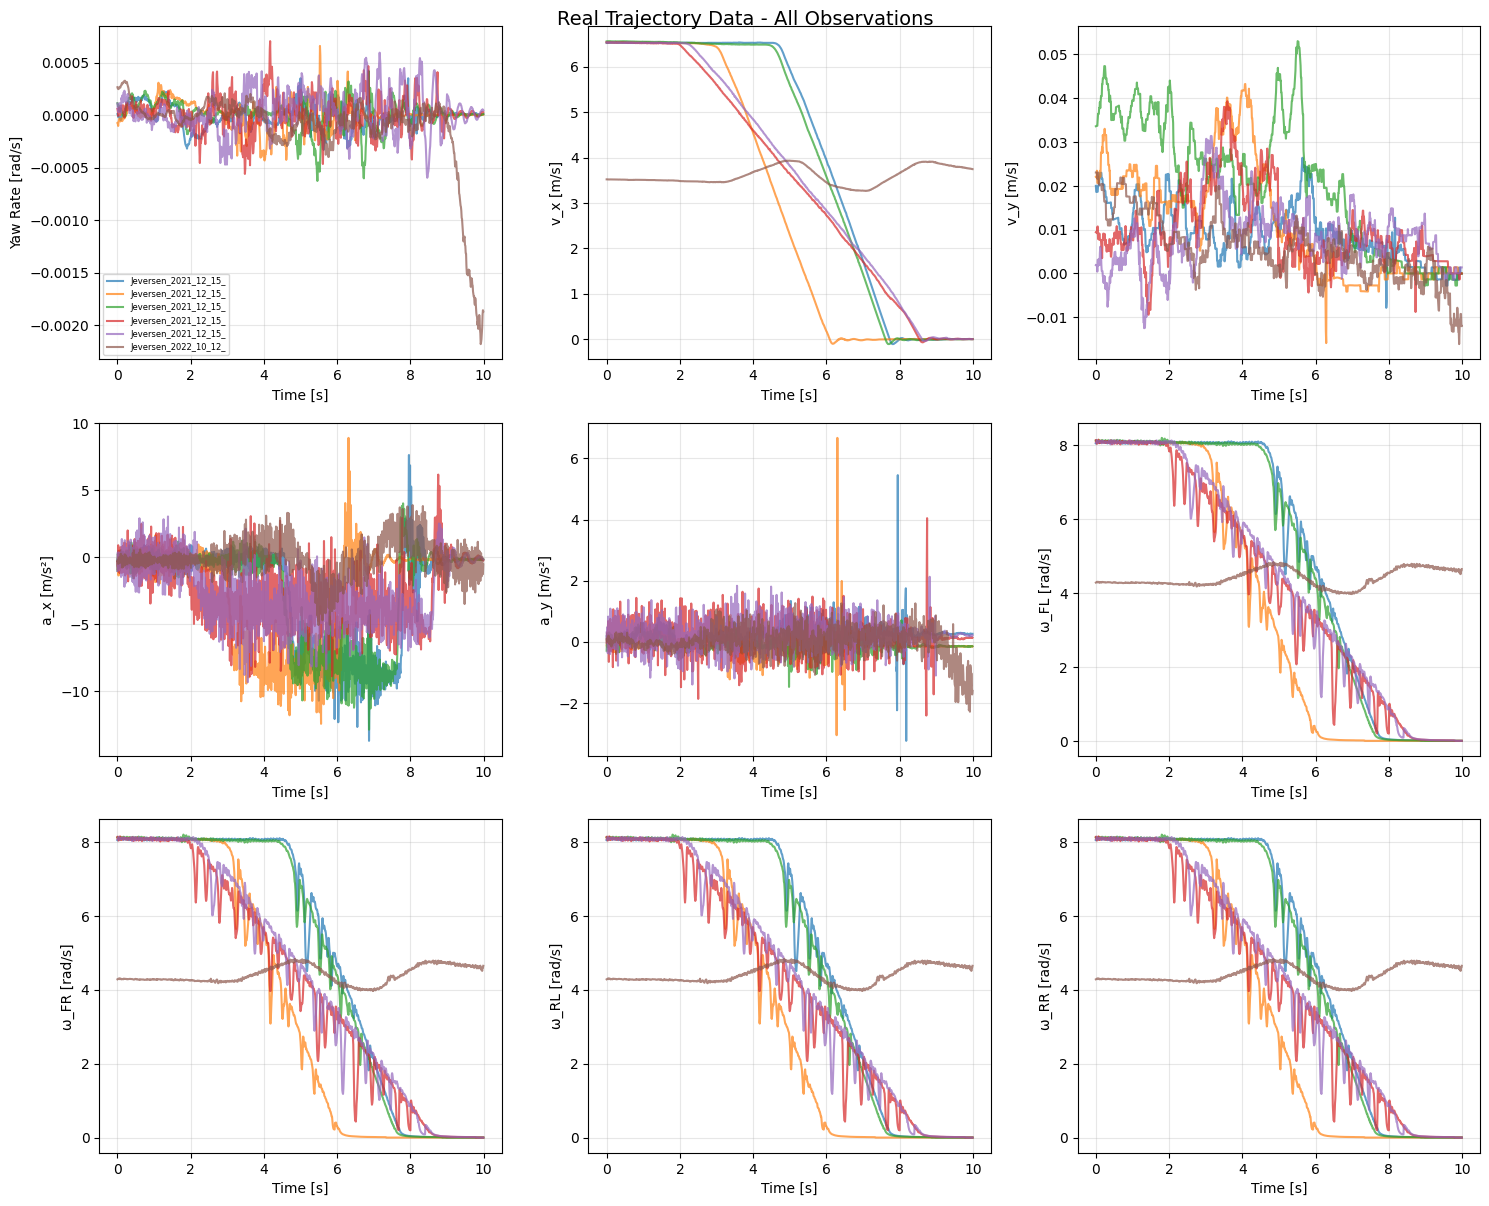

Visualized 6 trajectories across 9 observation channels


In [5]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

obs_labels = [
    "Yaw Rate [rad/s]",
    "v_x [m/s]",
    "v_y [m/s]",
    "a_x [m/s²]",
    "a_y [m/s²]",
    "ω_FL [rad/s]",
    "ω_FR [rad/s]",
    "ω_RL [rad/s]",
    "ω_RR [rad/s]",
]

for i, label in enumerate(obs_labels):
    ax = axes[i]
    for traj in trajectories:
        time = np.arange(T_SEG) * 0.01  # dt = 0.01s
        ax.plot(time, traj['x_obs'][:, i], alpha=0.7, label=traj['name'][:20])
    
    ax.set_xlabel('Time [s]')
    ax.set_ylabel(label)
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(fontsize=6, loc='best')

plt.tight_layout()
plt.suptitle('Real Trajectory Data - All Observations', y=1.001, fontsize=14)
plt.show()

print(f"Visualized {len(trajectories)} trajectories across 9 observation channels")

## 4. Define Optimization Problem

We'll minimize the Mean Squared Error (MSE) between simulated and real observations across all trajectories.

In [6]:
# JIT-compile simulation for speed
rollout_jit = jax.jit(rollout_with_states)

def simulate_trajectory(params_3d, controls, state0):
    """
    Simulate a trajectory given parameters.
    
    Args:
        params_3d: (mu, cd, m) as jnp.array
        controls: dict of control sequences
        state0: initial state
    
    Returns:
        y_seq: (T, 9) observations
    """
    _, y_seq = rollout_jit(params_3d, controls, state0)
    return y_seq


def compute_trajectory_mse(params_3d, traj_data):
    """
    Compute MSE between simulated and real observations for one trajectory.
    """
    y_sim = simulate_trajectory(
        params_3d,
        traj_data['controls'],
        traj_data['state0']
    )
    
    y_real = jnp.asarray(traj_data['x_obs'])
    
    # MSE across all timesteps and channels
    mse = jnp.mean((y_sim - y_real) ** 2)
    return float(mse)


def objective_function(params_array):
    """
    Objective function for optimization: total MSE across all trajectories.
    
    Args:
        params_array: [mu, cd, m] as numpy array
    
    Returns:
        Total MSE (scalar)
    """
    mu, cd, m = params_array
    params_3d = jnp.array([mu, cd, m], dtype=jnp.float32)
    
    total_mse = 0.0
    for traj in trajectories:
        mse = compute_trajectory_mse(params_3d, traj)
        total_mse += mse
    
    # Average MSE across trajectories
    avg_mse = total_mse / len(trajectories)
    
    return avg_mse


print("✓ Objective function defined")
print(f"  - Optimizing over {len(trajectories)} trajectories")
print(f"  - Each trajectory has {T_SEG} timesteps and 9 observation channels")

✓ Objective function defined
  - Optimizing over 6 trajectories
  - Each trajectory has 1000 timesteps and 9 observation channels


## 5. Test Objective Function with Default Parameters

In [7]:
# Default parameters from the model
default_mu = 1.0
default_cd = 0.27
default_m = 1720.0

default_params_array = np.array([default_mu, default_cd, default_m])

print("Testing objective function with default parameters...")
print(f"Parameters: μ={default_mu}, C_d={default_cd}, m={default_m}")

baseline_mse = objective_function(default_params_array)

print(f"\nBaseline MSE: {baseline_mse:.6f}")
print(f"Baseline RMSE: {np.sqrt(baseline_mse):.6f}")

Testing objective function with default parameters...
Parameters: μ=1.0, C_d=0.27, m=1720.0

Baseline MSE: 14.939777
Baseline RMSE: 3.865201


## 6. Run Global Optimization

We'll use Differential Evolution, a robust global optimization algorithm that doesn't require gradients.

In [8]:
# Parameter bounds from config
bounds = [
    (0.50, 1.50),   # mu (friction)
    (0.05, 0.60),   # cd (air resistance)
    (1700.0, 2200.0)  # m (mass)
]

print("Starting global optimization...")
print("\nParameter bounds:")
print(f"  μ  (friction):       [{bounds[0][0]:.2f}, {bounds[0][1]:.2f}]")
print(f"  C_d (air resist.):   [{bounds[1][0]:.2f}, {bounds[1][1]:.2f}]")
print(f"  m  (mass):           [{bounds[2][0]:.0f}, {bounds[2][1]:.0f}] kg")
print("\nThis may take several minutes...\n")

# Callback to track progress
iteration_count = [0]
best_mse = [float('inf')]

def callback(xk, convergence):
    iteration_count[0] += 1
    current_mse = objective_function(xk)
    if current_mse < best_mse[0]:
        best_mse[0] = current_mse
        print(f"Iter {iteration_count[0]:3d}: MSE={current_mse:.6f}, "
              f"μ={xk[0]:.4f}, C_d={xk[1]:.4f}, m={xk[2]:.1f}")

# Run optimization
result = differential_evolution(
    objective_function,
    bounds=bounds,
    strategy='best1bin',
    maxiter=100,
    popsize=15,
    tol=1e-6,
    mutation=(0.5, 1.5),
    recombination=0.7,
    seed=42,
    callback=callback,
    disp=True,
    workers=1,  # Use single worker for stability
)

print("\n" + "="*70)
print("OPTIMIZATION COMPLETE")
print("="*70)

Starting global optimization...

Parameter bounds:
  μ  (friction):       [0.50, 1.50]
  C_d (air resist.):   [0.05, 0.60]
  m  (mass):           [1700, 2200] kg

This may take several minutes...

differential_evolution step 1: f(x)= 14.689470609029135
Iter   1: MSE=14.689471, μ=0.6369, C_d=0.5450, m=1747.5
differential_evolution step 2: f(x)= 14.689470609029135
differential_evolution step 3: f(x)= 14.624061425526937
Iter   3: MSE=14.624061, μ=0.6037, C_d=0.5850, m=1736.5
differential_evolution step 4: f(x)= 14.556916077931723
Iter   4: MSE=14.556916, μ=0.5182, C_d=0.5787, m=1741.6
differential_evolution step 5: f(x)= 14.556916077931723
differential_evolution step 6: f(x)= 14.507526079813639
Iter   6: MSE=14.507526, μ=0.5052, C_d=0.5504, m=1718.6
differential_evolution step 7: f(x)= 14.507526079813639
differential_evolution step 8: f(x)= 14.482900619506836
Iter   8: MSE=14.482901, μ=0.5020, C_d=0.5812, m=1714.7
differential_evolution step 9: f(x)= 14.479914665222168
Iter   9: MSE=14.47

## 7. Results Analysis

In [9]:
# Extract optimized parameters
opt_mu, opt_cd, opt_m = result.x
opt_mse = result.fun

print("\n" + "="*70)
print("PARAMETER ESTIMATION RESULTS")
print("="*70)
print("\nOptimized Parameters:")
print(f"  μ  (friction):       {opt_mu:.4f}  (default: {default_mu:.4f})")
print(f"  C_d (air resist.):   {opt_cd:.4f}  (default: {default_cd:.4f})")
print(f"  m  (mass):           {opt_m:.1f} kg  (default: {default_m:.1f} kg)")

print("\nFit Quality:")
print(f"  Optimized MSE:       {opt_mse:.6f}")
print(f"  Optimized RMSE:      {np.sqrt(opt_mse):.6f}")
print(f"  Baseline MSE:        {baseline_mse:.6f}")
print(f"  Improvement:         {((baseline_mse - opt_mse) / baseline_mse * 100):.2f}%")

print("\nParameter Changes:")
print(f"  Δμ:   {(opt_mu - default_mu):+.4f} ({(opt_mu/default_mu - 1)*100:+.2f}%)")
print(f"  ΔC_d: {(opt_cd - default_cd):+.4f} ({(opt_cd/default_cd - 1)*100:+.2f}%)")
print(f"  Δm:   {(opt_m - default_m):+.1f} kg ({(opt_m/default_m - 1)*100:+.2f}%)")

print("\nOptimization Info:")
print(f"  Iterations:          {result.nit}")
print(f"  Function evals:      {result.nfev}")
print(f"  Success:             {result.success}")
print(f"  Message:             {result.message}")

# Store results for later use
optimized_params = {
    'mu': opt_mu,
    'cd': opt_cd,
    'm': opt_m,
    'mse': opt_mse,
    'rmse': np.sqrt(opt_mse),
}


PARAMETER ESTIMATION RESULTS

Optimized Parameters:
  μ  (friction):       0.5000  (default: 1.0000)
  C_d (air resist.):   0.6000  (default: 0.2700)
  m  (mass):           1700.0 kg  (default: 1720.0 kg)

Fit Quality:
  Optimized MSE:       14.442993
  Optimized RMSE:      3.800394
  Baseline MSE:        14.939777
  Improvement:         3.33%

Parameter Changes:
  Δμ:   -0.5000 (-50.00%)
  ΔC_d: +0.3300 (+122.22%)
  Δm:   -20.0 kg (-1.16%)

Optimization Info:
  Iterations:          91
  Function evals:      4144
  Success:             True
  Message:             Optimization terminated successfully.


## 8. Compare Simulations: Default vs Optimized Parameters

In [10]:
# Select first trajectory for detailed comparison
test_traj = trajectories[0]
print(f"Comparing on trajectory: {test_traj['name']}")

# Simulate with default parameters
params_default = jnp.array([default_mu, default_cd, default_m], dtype=jnp.float32)
y_sim_default = simulate_trajectory(
    params_default,
    test_traj['controls'],
    test_traj['state0']
)

# Simulate with optimized parameters
params_opt = jnp.array([opt_mu, opt_cd, opt_m], dtype=jnp.float32)
y_sim_opt = simulate_trajectory(
    params_opt,
    test_traj['controls'],
    test_traj['state0']
)

# Real data
y_real = test_traj['x_obs']

print("✓ Simulations complete")

Comparing on trajectory: Jeversen_2021_12_15_112328_Asphalt-Vollbremsung
✓ Simulations complete


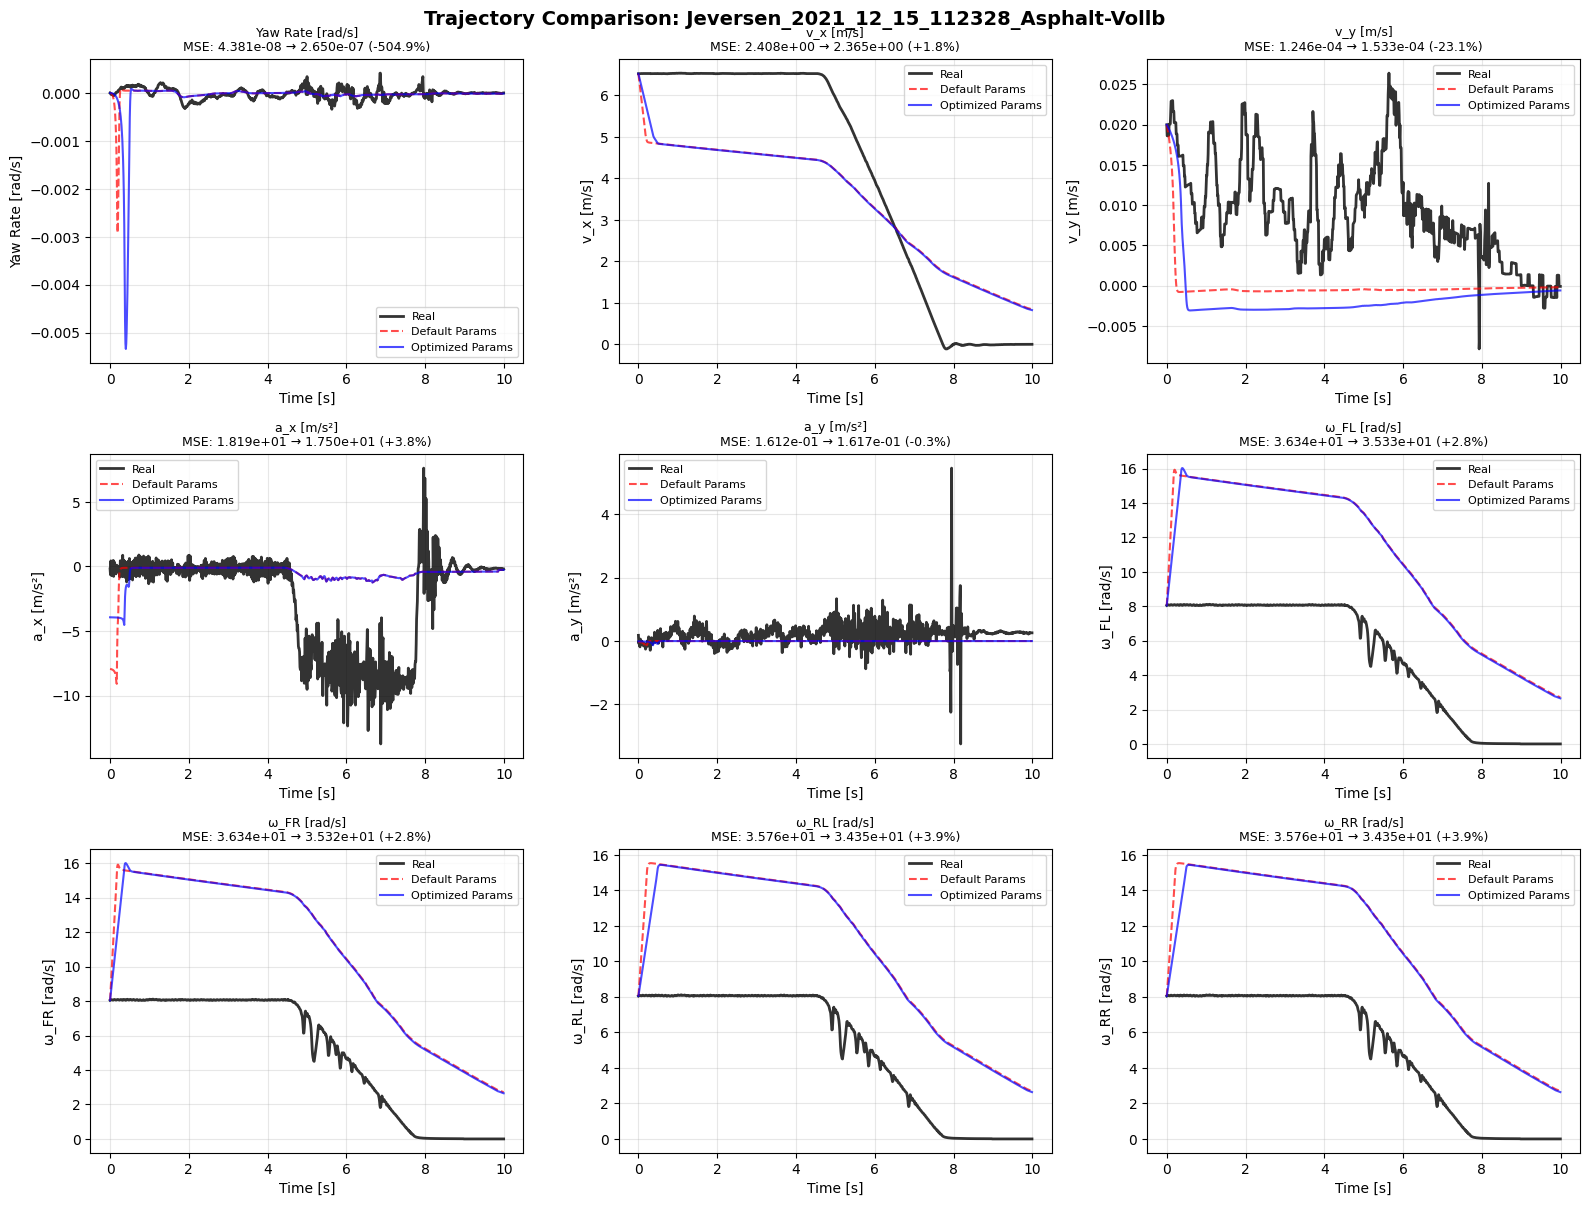

In [11]:
# Plot comparison
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

time = np.arange(T_SEG) * 0.01

for i, label in enumerate(obs_labels):
    ax = axes[i]
    
    # Plot real, default, and optimized
    ax.plot(time, y_real[:, i], 'k-', linewidth=2, label='Real', alpha=0.8)
    ax.plot(time, y_sim_default[:, i], 'r--', linewidth=1.5, label='Default Params', alpha=0.7)
    ax.plot(time, y_sim_opt[:, i], 'b-', linewidth=1.5, label='Optimized Params', alpha=0.7)
    
    ax.set_xlabel('Time [s]')
    ax.set_ylabel(label)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    
    # Compute channel-wise MSE
    mse_default = np.mean((y_sim_default[:, i] - y_real[:, i])**2)
    mse_opt = np.mean((y_sim_opt[:, i] - y_real[:, i])**2)
    improvement = (mse_default - mse_opt) / mse_default * 100
    
    ax.set_title(f'{label}\nMSE: {mse_default:.3e} → {mse_opt:.3e} ({improvement:+.1f}%)',
                 fontsize=9)

plt.tight_layout()
plt.suptitle(f'Trajectory Comparison: {test_traj["name"][:40]}',
             y=1.001, fontsize=14, fontweight='bold')
plt.show()

## 9. Evaluate on All Trajectories

In [12]:
# Compute MSE for each trajectory with both parameter sets
results_per_traj = []

for traj in trajectories:
    # Default params
    mse_default = compute_trajectory_mse(params_default, traj)
    
    # Optimized params
    mse_opt = compute_trajectory_mse(params_opt, traj)
    
    improvement = (mse_default - mse_opt) / mse_default * 100
    
    results_per_traj.append({
        'name': traj['name'],
        'mse_default': mse_default,
        'mse_optimized': mse_opt,
        'improvement_pct': improvement,
    })

# Create results DataFrame
results_df = pd.DataFrame(results_per_traj)

print("\n" + "="*90)
print("PER-TRAJECTORY RESULTS")
print("="*90)
print(results_df.to_string(index=False))

print("\n" + "="*90)
print("SUMMARY STATISTICS")
print("="*90)
print(f"Average MSE (Default):    {results_df['mse_default'].mean():.6f} ± {results_df['mse_default'].std():.6f}")
print(f"Average MSE (Optimized):  {results_df['mse_optimized'].mean():.6f} ± {results_df['mse_optimized'].std():.6f}")
print(f"Average Improvement:      {results_df['improvement_pct'].mean():.2f}% ± {results_df['improvement_pct'].std():.2f}%")
print(f"Best Improvement:         {results_df['improvement_pct'].max():.2f}% on {results_df.loc[results_df['improvement_pct'].idxmax(), 'name']}")
print(f"Worst Improvement:        {results_df['improvement_pct'].min():.2f}% on {results_df.loc[results_df['improvement_pct'].idxmin(), 'name']}")


PER-TRAJECTORY RESULTS
                                           name  mse_default  mse_optimized  improvement_pct
Jeversen_2021_12_15_112328_Asphalt-Vollbremsung    18.328852      17.708324         3.385522
  Jeversen_2021_12_15_125650_Beton-Vollbremsung    14.199631      13.585485         4.325079
  Jeversen_2021_12_15_125936_Beton-Vollbremsung    18.688072      18.049162         3.418813
 Jeversen_2021_12_15_134709_Basalt-Vollbremsung    10.725890      10.165910         5.220829
 Jeversen_2021_12_15_134858_Basalt-Vollbremsung    12.075675      11.486409         4.879775
                     Jeversen_2022_10_12_110132    15.620543      15.662668        -0.269675

SUMMARY STATISTICS
Average MSE (Default):    14.939777 ± 3.240578
Average MSE (Optimized):  14.442993 ± 3.253447
Average Improvement:      3.49% ± 1.99%
Best Improvement:         5.22% on Jeversen_2021_12_15_134709_Basalt-Vollbremsung
Worst Improvement:        -0.27% on Jeversen_2022_10_12_110132


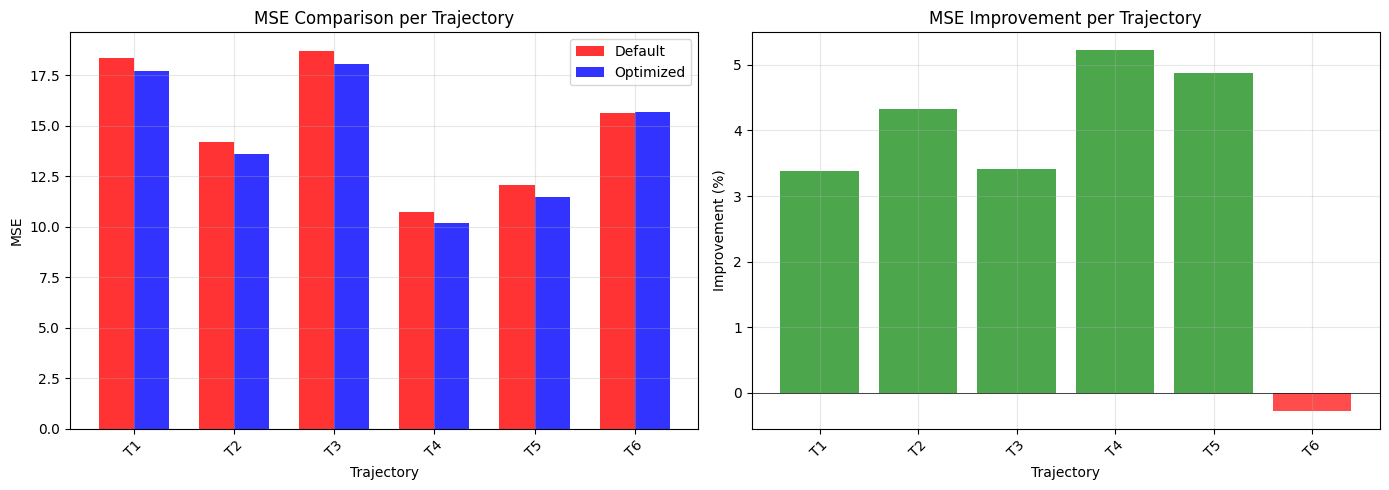

In [13]:
# Visualize improvements
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot of MSE comparison
x = np.arange(len(results_df))
width = 0.35

ax1.bar(x - width/2, results_df['mse_default'], width, label='Default', alpha=0.8, color='red')
ax1.bar(x + width/2, results_df['mse_optimized'], width, label='Optimized', alpha=0.8, color='blue')
ax1.set_xlabel('Trajectory')
ax1.set_ylabel('MSE')
ax1.set_title('MSE Comparison per Trajectory')
ax1.set_xticks(x)
ax1.set_xticklabels([f"T{i+1}" for i in range(len(results_df))], rotation=45)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Bar plot of improvement percentage
colors = ['green' if imp > 0 else 'red' for imp in results_df['improvement_pct']]
ax2.bar(x, results_df['improvement_pct'], color=colors, alpha=0.7)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.set_xlabel('Trajectory')
ax2.set_ylabel('Improvement (%)')
ax2.set_title('MSE Improvement per Trajectory')
ax2.set_xticks(x)
ax2.set_xticklabels([f"T{i+1}" for i in range(len(results_df))], rotation=45)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Save Results

In [14]:
import json
from datetime import datetime

# Prepare results for saving
save_results = {
    'timestamp': datetime.now().isoformat(),
    'num_trajectories': len(trajectories),
    'trajectory_length': T_SEG,
    'optimization': {
        'method': 'differential_evolution',
        'iterations': int(result.nit),
        'function_evals': int(result.nfev),
        'success': bool(result.success),
    },
    'default_parameters': {
        'mu': float(default_mu),
        'cd': float(default_cd),
        'm': float(default_m),
        'mse': float(baseline_mse),
    },
    'optimized_parameters': {
        'mu': float(opt_mu),
        'cd': float(opt_cd),
        'm': float(opt_m),
        'mse': float(opt_mse),
        'rmse': float(np.sqrt(opt_mse)),
    },
    'improvement': {
        'mse_reduction': float(baseline_mse - opt_mse),
        'mse_reduction_pct': float((baseline_mse - opt_mse) / baseline_mse * 100),
        'average_improvement_pct': float(results_df['improvement_pct'].mean()),
    },
    'per_trajectory_results': results_per_traj,
}

# Save to JSON
output_path = Path("../experiments/parameter_estimation_results.json")
output_path.parent.mkdir(parents=True, exist_ok=True)

with open(output_path, 'w') as f:
    json.dump(save_results, f, indent=2)

print(f"\n✓ Results saved to: {output_path}")

# Also save as CSV for easy viewing
csv_path = Path("../experiments/parameter_estimation_results.csv")
results_df.to_csv(csv_path, index=False)
print(f"✓ Per-trajectory results saved to: {csv_path}")


✓ Results saved to: ..\experiments\parameter_estimation_results.json
✓ Per-trajectory results saved to: ..\experiments\parameter_estimation_results.csv


## 11. Summary and Recommendations

**What we did:**
1. Loaded all available real trajectory data from multiple CSV files
2. Extracted consistent-length segments (1000 timesteps = 10 seconds)
3. Set up a global optimization problem to minimize simulation error
4. Used differential evolution to find optimal parameters (μ, C_d, m)
5. Evaluated fit quality across all trajectories

**Next steps:**
1. Update your config files to use the optimized parameters as new defaults
2. Re-run your SBI experiments with these better-calibrated parameters
3. Consider if you need to adjust the prior bounds based on the optimal values
4. Monitor if the improved simulation fidelity leads to better inference results

**Parameter Update Recommendations:**

In [15]:
print("\n" + "="*70)
print("RECOMMENDED PARAMETER UPDATES")
print("="*70)
print("\nUpdate these values in your configuration files:")
print("\nFor simulation/VehicleModel.py default_params:")
print(f"  'air_resistance': {opt_cd:.4f}  (currently: {default_cd:.4f})")
print(f"  'mass': {opt_m:.1f}  (currently: {default_m:.1f})")
print(f"  Note: friction (μ={opt_mu:.4f}) is typically a parameter, not in default_params")

print("\nFor configs/config.py fixed parameter values:")
print(f"  fixed_mu: {opt_mu:.4f}  (currently: {default_mu:.4f})")
print(f"  fixed_cd: {opt_cd:.4f}  (currently: {default_cd:.4f})")
print(f"  fixed_m: {opt_m:.1f}  (currently: {default_m:.1f})")

print("\nConsider adjusting prior bounds if optimized values are near boundaries:")
for param_name, param_val, lower, upper in [
    ('mu', opt_mu, 0.50, 1.50),
    ('cd', opt_cd, 0.05, 0.60),
    ('m', opt_m, 1700.0, 2200.0)
]:
    margin_lower = (param_val - lower) / (upper - lower)
    margin_upper = (upper - param_val) / (upper - lower)
    
    if margin_lower < 0.1:
        print(f"  ⚠ {param_name}={param_val:.4f} is close to lower bound {lower}")
    elif margin_upper < 0.1:
        print(f"  ⚠ {param_name}={param_val:.4f} is close to upper bound {upper}")
    else:
        print(f"  ✓ {param_name}={param_val:.4f} is well within bounds [{lower}, {upper}]")

print("\n" + "="*70)


RECOMMENDED PARAMETER UPDATES

Update these values in your configuration files:

For simulation/VehicleModel.py default_params:
  'air_resistance': 0.6000  (currently: 0.2700)
  'mass': 1700.0  (currently: 1720.0)
  Note: friction (μ=0.5000) is typically a parameter, not in default_params

For configs/config.py fixed parameter values:
  fixed_mu: 0.5000  (currently: 1.0000)
  fixed_cd: 0.6000  (currently: 0.2700)
  fixed_m: 1700.0  (currently: 1720.0)

Consider adjusting prior bounds if optimized values are near boundaries:
  ⚠ mu=0.5000 is close to lower bound 0.5
  ⚠ cd=0.6000 is close to upper bound 0.6
  ⚠ m=1700.0010 is close to lower bound 1700.0

